# Museum Visitors & City Population Analysis

This notebook demonstrates data loading, feature extraction, regression analysis, and visualization using the museums_db package.

## 1. Import Required Libraries and Modules
We start by importing the necessary libraries and the custom modules from the museums_db package.

In [6]:
# Import libraries and custom modules
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import pandas as pd
import matplotlib.pyplot as plt
import museums_db

# Configure database connection based on environment
if os.environ.get('JUPYTER_CONTAINER'):
    print("inside JUPYTER_NOTEBOOK condition")
    # Running inside Docker container
    os.environ['DB_HOST'] = 'db'
else:
    print("locally")
    # Running locally
    os.environ['DB_HOST'] = 'localhost'

print(f"DB_HOST = {os.environ['DB_HOST']}")


locally
DB_HOST = localhost


## 2. Select data from database

In [2]:
try:
    museum_city_data = museums_db.db.get_museum_city_data()
    df_select_data = pd.json_normalize(museum_city_data)
    print("Data loaded successfully")
except Exception as e:
    print(f"Error: {str(e)}")

Data loaded successfully


## 3. Prepare Data for Regression
Load the combined museum and city data from the database for analysis.

In [3]:
# Load museum and city data for regression
df = df_select_data.dropna(subset=['population'])
df.head()

,museum_name,city_name,country_name,annual_visitors,population
0,Louvre,Paris,France,8700000,2138551
1,National Museum of China,Beijing,China,6956800,18960744
2,Vatican Museums,Vatican City,Vatican,6825436,921
3,British Museum,London,United Kingdom,6479952,8961989
4,Natural History Museum,London,United Kingdom,6301972,8961989


## 6. Run Linear Regression
Fit a linear regression model to correlate city population with museum visitors.

In [4]:
# Run regression analysis
reg_model, coef, intercept, r2 = museums_db.run_regression(df)
print(f"Coefficient: {coef[0]:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R^2 Score: {r2:.2f}")

Coefficient: 0.04
Intercept: 3263743.47
R^2 Score: 0.03


## 7. Visualize Results
Plot the relationship between city population and museum visitors, along with the regression line.

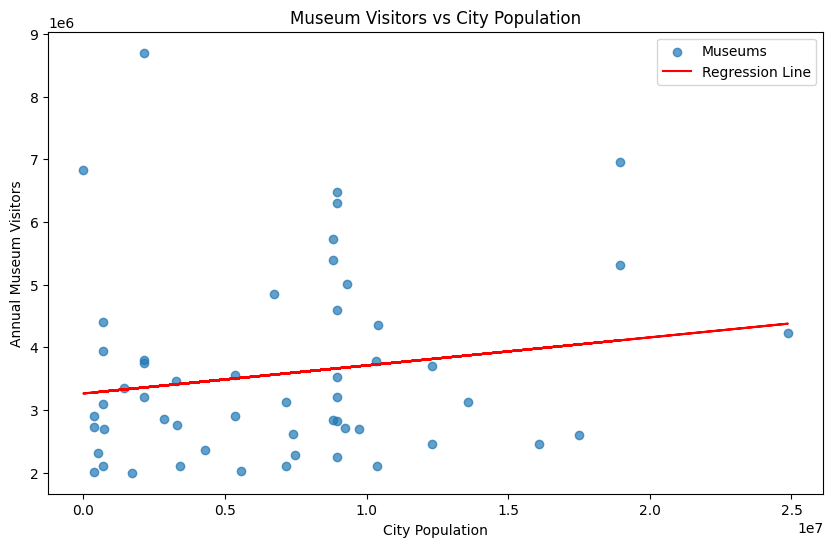

In [5]:
# Plot results
plt.figure(figsize=(10,6))
plt.scatter(df['population'], df['annual_visitors'], alpha=0.7, label='Museums')
plt.plot(df['population'], reg_model.predict(df[['population']]), color='red', label='Regression Line')
plt.xlabel('City Population')
plt.ylabel('Annual Museum Visitors')
plt.title('Museum Visitors vs City Population')
plt.legend()
plt.show()